In [2]:
import pandas as pd

file_path = r"..\..\data\raw\ev_charging_dataset.xlsx"

sessions = pd.read_excel(file_path, sheet_name="sessions")

print("Shape:", sessions.shape)
print("\nColumns:")
print(sessions.columns.tolist())

Shape: (294024, 15)

Columns:
['session_id', 'station_id', 'charger_id', 'charger_type', 'start_timestamp', 'end_timestamp', 'session_duration_minutes', 'energy_kwh', 'price_per_kwh', 'total_cost', 'payment_method', 'user_type', 'customer_id', 'station_region', 'year']


In [3]:
print("Unique customers:", sessions["customer_id"].nunique())
print("Missing customer IDs:", sessions["customer_id"].isna().sum())

print("\nSessions per customer:")
print(sessions.groupby("customer_id")["session_id"].count().describe())

Unique customers: 8000
Missing customer IDs: 0

Sessions per customer:
count    8000.000000
mean       36.753000
std        56.698012
min         1.000000
25%         2.500000
50%        18.000000
75%        40.000000
max       302.000000
Name: session_id, dtype: float64


In [8]:
customer_profiles = (
    sessions.groupby("customer_id")
    .agg(
        total_sessions=("session_id", "count"),
        total_energy_kwh=("energy_kwh", "sum"),
        avg_energy_per_session=("energy_kwh", "mean"),
        avg_session_duration=("session_duration_minutes", "mean"),
        total_spend=("total_cost", "sum"),
        avg_spend_per_session=("total_cost", "mean"),
        avg_price_per_kwh=("price_per_kwh", "mean")
    )
    .reset_index()
)

print(customer_profiles.shape)
customer_profiles.head()

(8000, 8)


,customer_id,total_sessions,total_energy_kwh,avg_energy_per_session,avg_session_duration,total_spend,avg_spend_per_session,avg_price_per_kwh
0,CUST_00001,267,12299.8,46.066667,35.179775,7257.86,27.182996,0.595468
1,CUST_00002,243,11619.2,47.815638,34.419753,6784.02,27.917778,0.585802
2,CUST_00003,282,13163.2,46.678014,35.574468,7819.69,27.729397,0.596702
3,CUST_00004,253,12144.4,48.001581,34.043478,7122.30,28.151383,0.589842
4,CUST_00005,246,11713.1,47.614228,35.313008,6882.25,27.976626,0.586707


In [13]:
customer_profiles.describe().T

,count,mean,std,min,25%,50%,75%,max
total_sessions,8000.0,36.753000,56.698012,1.00,2.500000,18.000000,40.000000,302.000
total_energy_kwh,8000.0,1726.093225,2667.198727,23.90,134.525000,851.500000,1888.975000,14358.100
avg_energy_per_session,8000.0,47.561497,9.133279,23.90,44.160536,46.862080,49.410261,80.000
avg_session_duration,8000.0,34.584621,7.311039,15.00,32.058824,34.902778,37.144643,60.000
total_spend,8000.0,1021.387515,1579.554298,11.87,82.402500,502.995000,1129.620000,8459.290
avg_spend_per_session,8000.0,27.163200,4.916117,11.87,25.602674,27.509211,28.997509,50.400
avg_price_per_kwh,8000.0,0.572552,0.041282,0.45,0.566667,0.588750,0.597919,0.654


In [15]:
customer_profiles[
    [
        "total_sessions",
        "total_energy_kwh",
        "avg_energy_per_session",
        "avg_session_duration",
        "total_spend",
        "avg_spend_per_session",
        "avg_price_per_kwh"
    ]
].skew().sort_values(ascending=False)

total_energy_kwh          2.976059
total_sessions            2.970429
total_spend               2.969197
avg_energy_per_session    1.587120
avg_session_duration      0.184931
avg_spend_per_session     0.120979
avg_price_per_kwh        -1.412400
dtype: float64

In [17]:
import numpy as np

log_features = [
    "total_sessions",
    "total_energy_kwh",
    "total_spend",
    "avg_energy_per_session"
]

customer_model_data = customer_profiles.copy()

for feature in log_features:
    customer_model_data[feature] = np.log1p(
        customer_model_data[feature]
    )

In [18]:
customer_model_data[log_features].skew().sort_values(ascending=False)

avg_energy_per_session    0.438692
total_sessions           -0.171796
total_energy_kwh         -0.441523
total_spend              -0.480851
dtype: float64

In [19]:
from sklearn.preprocessing import StandardScaler

features = [
    "total_sessions",
    "total_energy_kwh",
    "avg_energy_per_session",
    "avg_session_duration",
    "total_spend",
    "avg_spend_per_session",
    "avg_price_per_kwh"
]

scaler = StandardScaler()

X = scaler.fit_transform(
    customer_model_data[features]
)

print("Shape:", X.shape)

Shape: (8000, 7)


In [20]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

print(inertia)

[31182.414654408007, 15980.00551128275, 11669.95727345987, 7459.226872262492, 5944.608609713838, 5317.745080503057, 4814.99982098242]


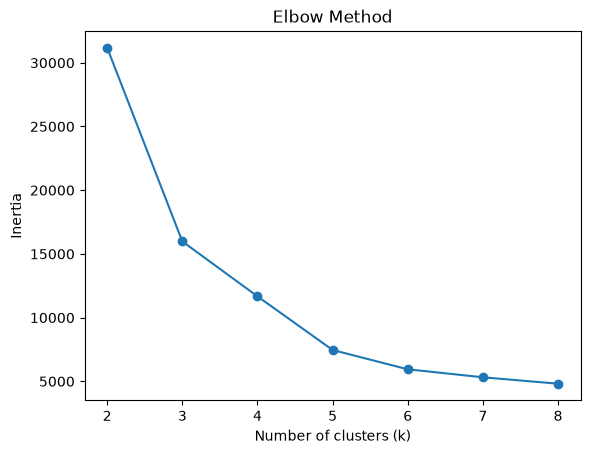

In [24]:
import matplotlib.pyplot as plt

plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [25]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    silhouette_scores[k] = silhouette_score(
        X,
        labels
    )

print(silhouette_scores)

{2: 0.5881043698325578, 3: 0.6530762069150255, 4: 0.48419066449375225, 5: 0.5119636871386284, 6: 0.4683801801803734, 7: 0.48680716030009247, 8: 0.4663963922992808}


In [26]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_model_data["segment"] = final_kmeans.fit_predict(X)

print(
    customer_model_data["segment"].value_counts()
    .sort_index()
)

segment
0     779
1    5996
2    1225
Name: count, dtype: int64


In [28]:
customer_segmented = customer_profiles.copy()

customer_segmented["segment"] = customer_model_data["segment"].values

In [29]:
segment_profile = (
    customer_segmented
    .groupby("segment")[features]
    .mean()
    .round(2)
)

segment_profile

,total_sessions,total_energy_kwh,avg_energy_per_session,avg_session_duration,total_spend,avg_spend_per_session,avg_price_per_kwh
segment,,,,,,,
0,1.02,33.85,33.15,49.72,17.41,17.01,0.51
1,48.70,2286.24,46.89,35.10,1354.18,27.77,0.59
2,1.01,60.47,59.99,22.44,30.93,30.66,0.51


In [30]:
segment_user_type = pd.crosstab(
    customer_segmented["segment"],
    sessions.groupby("customer_id")["user_type"].first()
)

segment_user_type

user_type,delivery,fleet,public,taxi
segment,,,,
0,208,175,202,194
1,1459,1470,1593,1474
2,316,300,289,320


In [31]:
segment_user_type_pct = pd.crosstab(
    customer_segmented["segment"],
    sessions.groupby("customer_id")["user_type"].first(),
    normalize="index"
) * 100

segment_user_type_pct.round(2)

user_type,delivery,fleet,public,taxi
segment,,,,
0,26.70,22.46,25.93,24.90
1,24.33,24.52,26.57,24.58
2,25.80,24.49,23.59,26.12


In [43]:
print(customer_segmented.columns.tolist())
print(customer_segmented.shape)

['customer_id', 'total_sessions', 'total_energy_kwh', 'avg_energy_per_session', 'avg_session_duration', 'total_spend', 'avg_spend_per_session', 'avg_price_per_kwh', 'segment', 'segment_name']
(8000, 10)


In [44]:
customer_segmented = customer_profiles.copy().reset_index()

customer_segmented["segment"] = customer_model_data["segment"].values

customer_segmented["segment_name"] = (
    customer_segmented["segment"].map(segment_names)
)

print(customer_segmented.columns.tolist())
print(customer_segmented.shape)

['customer_id', 'total_sessions', 'total_energy_kwh', 'avg_energy_per_session', 'avg_session_duration', 'total_spend', 'avg_spend_per_session', 'avg_price_per_kwh', 'segment', 'segment_name']
(8000, 10)


In [45]:
customer_segmented[["customer_id", "segment", "segment_name"]].head()

,customer_id,segment,segment_name
0,CUST_00001,1,Frequent High-Value Users
1,CUST_00002,1,Frequent High-Value Users
2,CUST_00003,1,Frequent High-Value Users
3,CUST_00004,1,Frequent High-Value Users
4,CUST_00005,1,Frequent High-Value Users


In [46]:
customer_profiles.to_csv(
    r"..\..\tasks\task_04_customer_segmentation\analysis\user_profiles.csv",
    index=False
)

In [47]:
customer_segmented.to_csv(
    r"..\..\tasks\task_04_customer_segmentation\analysis\user_segments.csv",
    index=False
)

In [48]:
print("User profiles:", customer_profiles.shape)
print("User segments:", customer_segmented.shape)

User profiles: (8000, 7)
User segments: (8000, 10)
